In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from statsmodels.regression.linear_model import OLS
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt


In [2]:
# Define start and end dates
start_date = '2020-01-01'
end_date = '2023-01-01'

# Function to download data
def download_data(stock):
    data = yf.download(stock, start=start_date, end=end_date)
    return data['Adj Close']

In [3]:
# Function to calculate hedge ratio and spread
def calculate_spread(stock_a, stock_b):
    x = stock_a
    y = stock_b
    
    # Combine the data into a single DataFrame
    data = pd.concat([x, y], axis=1)
    data.columns = ['Stock A', 'Stock B']
    
    # Ensuring the index is in datetime format
    data.index = pd.to_datetime(data.index)
    
    # Drop rows with any NaNs or infinite values
    data = data.replace([np.inf, -np.inf], np.nan).dropna()
    
    # Performing the linear regression
    model = OLS(data['Stock A'], data['Stock B'])
    model = model.fit()
    
    # Calculating the spread
    data['spread'] = data['Stock A'] - model.params[0] * data['Stock B']
    
    return data, model.params[0]

In [4]:
# Function to perform rolling ADF test
def rolling_adf(spread, window):
    adf_results = []
    for start in range(len(spread) - window + 1):
        end = start + window
        adf_result = adfuller(spread[start:end], maxlag=1)
        adf_results.append(adf_result[0])  # Appending the ADF test statistic
    return pd.Series(adf_results, index=spread.index[window-1:])

In [5]:
# Define the stock pairs
stock_a = 'HDFCBANK.NS'
stock_b = 'KOTAKBANK.NS'

# Download data
stock_a_data = download_data(stock_a)
stock_b_data = download_data(stock_b)

# Calculate spread
data, hedge_ratio = calculate_spread(stock_a_data, stock_b_data)

# Perform rolling ADF test
window = 90
adf_results = rolling_adf(data['spread'], window)

# Combine ADF results with the original data
data['adf_results'] = np.nan
data.loc[adf_results.index, 'adf_results'] = adf_results.values


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed


In [6]:
# Function to implement the optimized mean reversion strategy
def mean_reversion_strategy_optimized(data, lookback, std_dev, adf_threshold):
    # Calculate Moving Average and Standard Deviation before filtering
    data['moving_average'] = data.spread.rolling(lookback).mean()
    data['moving_std_dev'] = data.spread.rolling(lookback).std()

    # Calculate Upper and Lower Bands
    data['upper_band'] = data.moving_average + std_dev * data.moving_std_dev
    data['lower_band'] = data.moving_average - std_dev * data.moving_std_dev

    # Filter only the dates where ADF test indicates stationarity
    data_filtered = data[data['adf_results'] < adf_threshold].copy()

    # Long Positions
    data_filtered['long_entry'] = data_filtered.spread < data_filtered.lower_band
    data_filtered['long_exit'] = data_filtered.spread >= data_filtered.moving_average

    data_filtered['positions_long'] = np.nan
    data_filtered.loc[data_filtered.long_entry, 'positions_long'] = 1
    data_filtered.loc[data_filtered.long_exit, 'positions_long'] = 0
    data_filtered.positions_long = data_filtered.positions_long.fillna(method='ffill')

    # Short Positions
    data_filtered['short_entry'] = data_filtered.spread > data_filtered.upper_band
    data_filtered['short_exit'] = data_filtered.spread <= data_filtered.moving_average

    data_filtered['positions_short'] = np.nan
    data_filtered.loc[data_filtered.short_entry, 'positions_short'] = -1
    data_filtered.loc[data_filtered.short_exit, 'positions_short'] = 0
    data_filtered.positions_short = data_filtered.positions_short.fillna(method='ffill')

    # Combine Long and Short Positions
    data_filtered['positions'] = data_filtered.positions_long + data_filtered.positions_short

    return data_filtered


In [7]:
# Example Usage
lookback = 60
std_dev = 1.5
adf_threshold = -2.00  # Use appropriate critical value threshold

data_with_signals = mean_reversion_strategy_optimized(data, lookback, std_dev, adf_threshold)
print(data_with_signals)

# Function to calculate strategy returns
def calculate_strategy_returns(data):
    # Calculate daily returns for both stocks
    data['returns_A'] = data['Stock A'].pct_change()
    data['returns_B'] = data['Stock B'].pct_change()

    # Calculate the returns of the spread
    data['spread_returns'] = data['returns_A'] - hedge_ratio * data['returns_B']

    # Calculate strategy returns based on positions
    data['strategy_returns'] = data['positions'].shift(1) * data['spread_returns']

    # Calculate cumulative returns
    data['cumulative_strategy_returns'] = (1 + data['strategy_returns']).cumprod()

    return data

# Calculate the strategy returns
data_with_returns = calculate_strategy_returns(data_with_signals)

# Display the result
print(data_with_returns[['strategy_returns', 'cumulative_strategy_returns']])


                Stock A      Stock B     spread  adf_results  moving_average  \
Date                                                                           
2020-05-14   857.932861  1169.566284 -42.485082    -2.935973      -97.170029   
2020-05-15   852.605042  1174.750610 -51.804177    -2.920113      -96.079004   
2020-05-18   803.166077  1110.295410 -51.620799    -2.822310      -95.184420   
2020-05-19   797.406250  1127.044800 -70.275535    -2.917190      -94.361170   
2020-05-20   822.797607  1156.605469 -67.642149    -2.907059      -93.328987   
...                 ...          ...        ...          ...             ...   
2022-11-28  1560.793213  1924.454468  79.206955    -2.722950        8.523864   
2022-11-29  1558.452393  1921.859375  78.864028    -2.698589       10.276496   
2022-11-30  1568.791016  1943.318237  72.682044    -2.539247       11.913986   
2022-12-01  1579.568604  1930.592651  93.256722    -2.178193       13.983113   
2022-12-02  1567.474365  1927.099365  83

In [8]:
# Check the number of long and short entries
num_long_entries = data_with_signals['long_entry'].sum()
num_short_entries = data_with_signals['short_entry'].sum()

print(f"Number of Long Entries: {num_long_entries}")
print(f"Number of Short Entries: {num_short_entries}")


Number of Long Entries: 8
Number of Short Entries: 48


After relaxing only the standard deviation multiplier (std_dev) and the ADF test threshold (adf_threshold), we have significantly more trading signals: 8 long entries and 48 short entries. This suggests that the adjustments allowed the strategy to identify more trading opportunities.

Interpretation of Results Higher Number of Short Entries: The much higher number of short entries compared to long entries indicates that the spread was more frequently above the upper band than below the lower band. This could suggest that: The spread tends to revert downwards more often. The adjusted parameters may be better suited for identifying overbought conditions rather than oversold ones. Effectiveness of Adjustments:

Relaxing the ADF Threshold: By setting a less stringent ADF threshold (e.g., -2.0), more periods passed the stationarity test, allowing more data points to be considered for generating signals. Lowering the Standard Deviation Multiplier (std_dev): This adjustment made it easier for the spread to breach the upper and lower bands, resulting in more frequent trading signals.

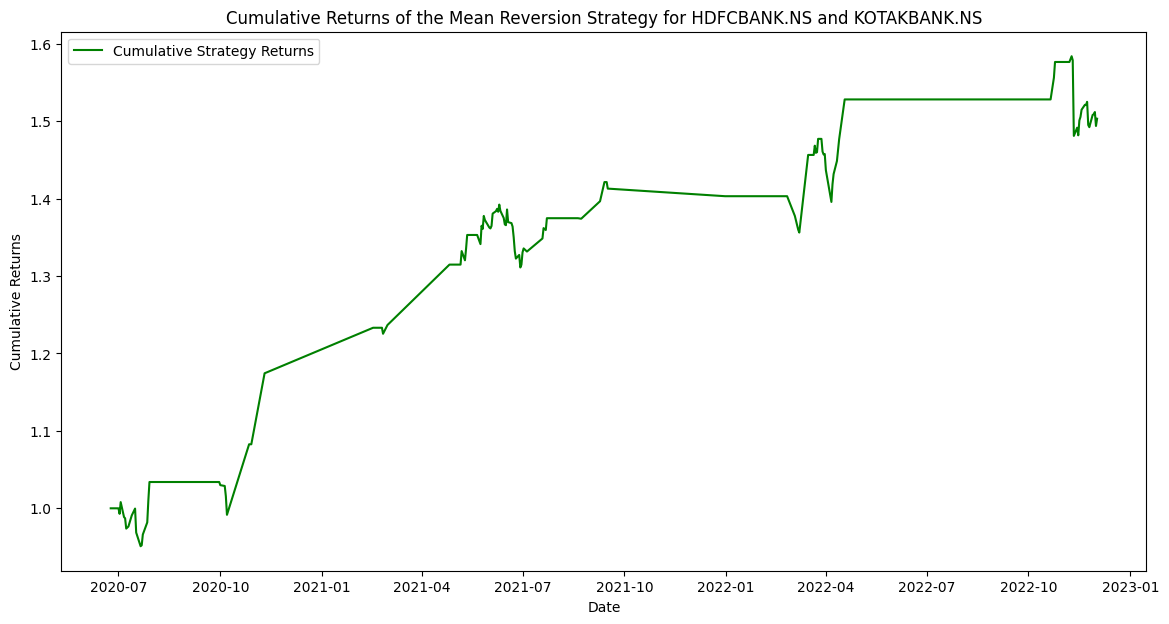

In [9]:
# Plot cumulative returns
plt.figure(figsize=(14, 7))
plt.plot(data_with_returns.index, data_with_returns['cumulative_strategy_returns'], label='Cumulative Strategy Returns', color='green')
plt.title(f'Cumulative Returns of the Mean Reversion Strategy for {stock_a} and {stock_b}')
plt.xlabel('Date')
plt.ylabel('Cumulative Returns')
plt.legend()
plt.show()


In [10]:
def calculate_performance_metrics(data):
    # Total return
    total_return = data['cumulative_strategy_returns'].iloc[-1] - 1

    # Annualized Sharpe ratio
    daily_returns = data['strategy_returns']
    sharpe_ratio = np.sqrt(252) * daily_returns.mean() / daily_returns.std()

    # Maximum drawdown
    cumulative_returns = data['cumulative_strategy_returns']
    drawdown = cumulative_returns / cumulative_returns.cummax() - 1
    max_drawdown = drawdown.min()

    return total_return, sharpe_ratio, max_drawdown

# Calculate performance metrics
total_return, sharpe_ratio, max_drawdown = calculate_performance_metrics(data_with_returns)

# Display results
print(f"Total Return: {total_return:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Maximum Drawdown: {max_drawdown:.2%}")

Total Return: 50.30%
Sharpe Ratio: 1.98
Maximum Drawdown: -6.50%


In [11]:
# Check for missing values in the calculated columns
missing_values = data[['moving_average', 'moving_std_dev', 'upper_band', 'lower_band']].isna().sum()

print("Missing values in each column:")
print(missing_values)


Missing values in each column:
moving_average    59
moving_std_dev    59
upper_band        59
lower_band        59
dtype: int64


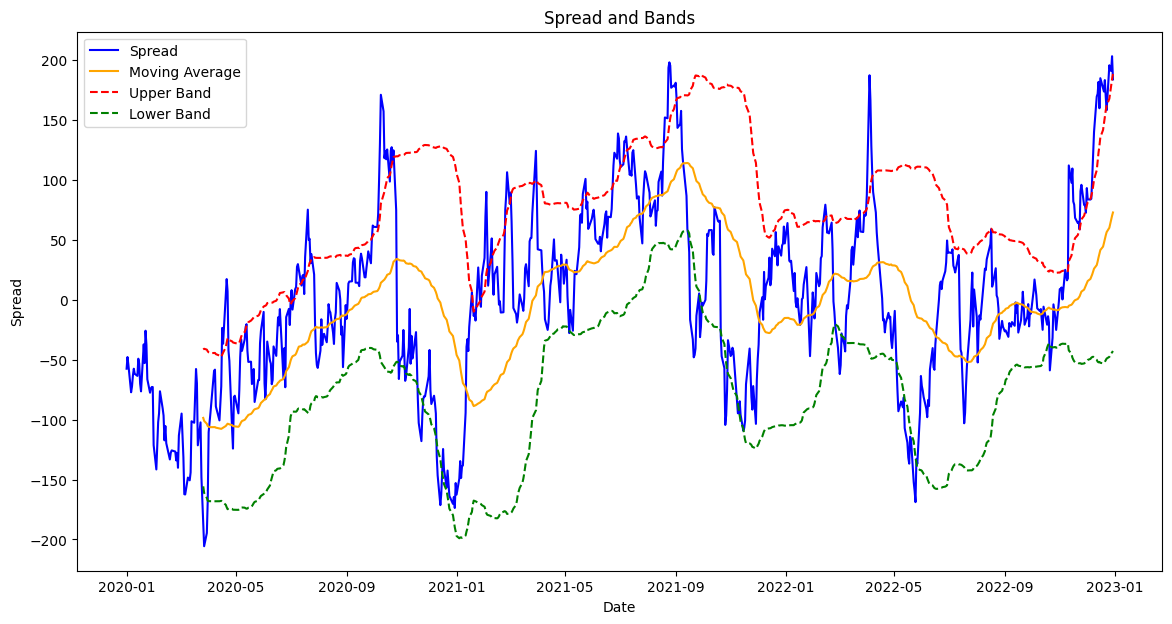

In [12]:
plt.figure(figsize=(14, 7))
plt.plot(data['spread'], label='Spread', color='blue')
plt.plot(data['moving_average'], label='Moving Average', color='orange')
plt.plot(data['upper_band'], label='Upper Band', color='red', linestyle='--')
plt.plot(data['lower_band'], label='Lower Band', color='green', linestyle='--')
plt.title('Spread and Bands')
plt.xlabel('Date')
plt.ylabel('Spread')
plt.legend()
plt.show()

The output confirms that the missing values in the moving_average, moving_std_dev, upper_band, and lower_band columns are due to the rolling window size of 60 days. This is expected because a rolling calculation requires a minimum number of observations (in this case, 60 days) to compute the first moving average and standard deviation.

No Further Gaps: Since there are no other missing values after the initial 59 observations, it indicates that the data is continuous and that there are no gaps introduced by the rolling calculations or other filtering processes.